# Task 2: Multi-Head Attention and a Full Transformer Decoder

This notebook contains the complete implementation of Task 2 from the Seasons of Code VLM Mentee Handbook. It includes the code, conceptual writeups, and explanations of the **Curiosity Corners** directly alongside the code they relate to. By the end of this notebook, you will have trained a 0.82M parameter decoder-only transformer.

In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F

# --- HYPERPARAMETERS ---
batch_size = 64
block_size = 64
max_iters = 5000
eval_interval = 500
learning_rate = 3e-4
n_embd = 128
n_head = 4
n_layer = 4
dropout = 0.2

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


## Data Loading
We use the Tiny Shakespeare dataset. We build a character-level vocabulary and split the dataset into 90% training and 10% validation data. The `get_batch` function fetches random chunks of size `block_size` to feed into the model.

In [2]:
# Load the dataset (ensure input.txt is in your directory)
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

chars = sorted(list(set(text)))
vocab_size = len(chars)

stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9 * len(data))
train_data = data[:n]
val_data = data[n:]

def get_batch(split):
    data_split = train_data if split == 'train' else val_data
    ix = torch.randint(len(data_split) - block_size, (batch_size,))
    x = torch.stack([data_split[i:i+block_size] for i in ix])
    y = torch.stack([data_split[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

## Part A: Multi-Head Attention

A single attention head looks at the sequence in one specific way. **Multi-Head Attention** runs several heads in parallel, each with its own learned projections (Q, K, V). This allows different heads to specialize (e.g., one tracks grammar, another tracks vocabulary).

> 💡 **CURIOSITY CORNER: The for-loop is not how production code does it**
> In `MultiHeadAttention`, we use a Python list comprehension `[h(x) for h in self.heads]` and `torch.cat`. This is mathematically correct and easy to read, but slow! In real production code, heads are computed as a single batched matrix multiplication by reshaping the tensors. Modern PyTorch models also use **FlashAttention**, which keeps calculations in the super-fast GPU SRAM instead of slow HBM memory, giving a 2-4x speedup automatically.
>
> 💡 **CURIOSITY CORNER: Dropout — what and why**
> You'll see `nn.Dropout(0.2)` in the code below. Dropout randomly zeroes out 20% of the activations during training. This prevents "co-adaptation" (neurons relying too heavily on specific other neurons), forcing the network to learn robust, redundant representations. It acts as a form of stochastic regularization, almost like training an ensemble of subnetworks!

In [3]:
class Head(nn.Module):
    def __init__(self, n_embd, head_size, block_size):
        super().__init__()
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        v = self.value(x)

        wei = q @ k.transpose(-2, -1) * (C ** -0.5)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ v

class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, head_size, block_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size) for _ in range(n_head)])
        self.proj = nn.Linear(n_head * head_size, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.dropout(self.proj(out))

## Part B: The Transformer Block

A Transformer block wraps four pieces: Multi-Head Attention, a Feed-Forward Network (MLP), two LayerNorms, and two residual connections.

**The MLP's Role:** While Attention mixes information *across* different positions in the sequence, the MLP processes that gathered information *independently* within each token.

> 💡 **CURIOSITY CORNER: ReLU is fine; modern transformers use GELU or SwiGLU**
> We use `nn.ReLU()` in our FeedForward network because it's simple and fast. However, modern models like GPT-2 use **GELU**, which has a smooth, non-monotonic curve around zero. Even newer models like LLaMA use **SwiGLU**, which doubles the parameters but gives much better performance per parameter spent. For our Tiny Shakespeare model, ReLU works perfectly well.
>
> 💡 **CURIOSITY CORNER: Why residual connections matter so much**
> Notice the `x = x + ...` pattern in the `Block`. These are **Residual Connections**. They provide an unobstructed "highway" for gradients to flow backward through the network. Without them, gradients vanish after passing through many layers of matrix multiplications, making deep networks impossible to train. Our ablation experiments proved how catastrophic removing these connections can be.

In [4]:
class FeedForward(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        head_size = n_embd // n_head
        self.attn = MultiHeadAttention(n_embd, n_head, head_size, block_size)
        self.ffn = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # Pre-norm architecture with residual connections
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x

## The Full Language Model
Here we stack 4 Transformer Blocks, generate token and position embeddings, and project the output into logits mapping to our vocabulary.

In [5]:
class LanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[Block(n_embd, n_head, block_size) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))

        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None:
            return logits, None

        B, T, C = logits.shape
        logits = logits.view(B * T, C)
        targets = targets.view(B * T)
        loss = F.cross_entropy(logits, targets)
        return logits, loss

model = LanguageModel(vocab_size).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

Total parameters: 0.82 M


## Training the Model

We are ready to train! We use the **AdamW** optimizer. Unlike basic SGD, AdamW adapts the learning rate for each individual parameter, which is essential for handling the different gradient magnitudes across embeddings, attention layers, and MLPs.

> 💡 **CURIOSITY CORNER: Learning rate scheduling — the warmup-cosine recipe**
> The handbook instructed us to use a constant learning rate of `3e-4`. Real-world LLMs use a schedule: a linear warmup followed by a cosine decay down to 10% of peak.
>
> *Why didn't we use it here?* Because our model is tiny (0.82M parameters) and we only train for 5000 steps! We proved this in our experiments: forcing a warmup meant the model wasted the first 1000 steps tip-toeing and never reached its full potential. Constant LR is the best choice for this specific small-scale task.

In [6]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print("Starting training...")
for iter in range(max_iters):
    if iter % eval_interval == 0 or iter == max_iters - 1:
        model.eval()
        with torch.no_grad():
            xb, yb = get_batch('val')
            _, val_loss = model(xb, yb)
        print(f"Step {iter}: val loss {val_loss.item():.4f}")
        model.train()

    xb, yb = get_batch('train')
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

Starting training...
Step 0: val loss 4.3838
Step 500: val loss 2.3367
Step 1000: val loss 2.0929
Step 1500: val loss 1.9848
Step 2000: val loss 1.8989
Step 2500: val loss 1.8663
Step 3000: val loss 1.8291
Step 3500: val loss 1.7591
Step 4000: val loss 1.8640
Step 4500: val loss 1.7308
Step 4999: val loss 1.7206


## Text Generation
Once trained (with a loss around ~1.76), we can sample from the model's learned probabilities to generate 300 characters of Shakespeare-esque text.

In [7]:
print("\nTraining complete! Generating text sample...")

model.eval()
context = torch.zeros((1, 1), dtype=torch.long, device=device)
generated_tokens = []

with torch.no_grad():
    for _ in range(300):
        idx_cond = context[:, -block_size:]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :]
        probs = F.softmax(logits, dim=-1)
        idx_next = torch.multinomial(probs, num_samples=1)
        context = torch.cat((context, idx_next), dim=1)
        generated_tokens.append(idx_next.item())

print("\n--- Generated Text ---\n")
print(decode(generated_tokens))


Training complete! Generating text sample...

--- Generated Text ---

Till me withalks may mustle gentlemong be.

BENVOLIO:
In price is is love vourk a passions to day to he:
Fass his no more ingeldring death means:
Good some more breat leary of the sonse make out
On thire your receives deso words me to disconse,
And husber his no very for she stand munt man!

POMINIU


Part D: Ablation Experiments Analysis

Variant 1 — Baseline (Full Architecture)
Our baseline model trained smoothly over 5,000 steps, with the validation loss rapidly descending from an initialized ~4.33 down to roughly ~1.72. This represents healthy gradient flow. The residual connections provided an uninterrupted "highway" for the gradient signal to travel all the way from the final loss calculation back to the initial embedding layers. Meanwhile, the LayerNorms ensured that at every branch off this highway, the inputs to the Attention and Feed-Forward networks remained centered with a variance of 1, keeping the model stable and within the "sweet spot" for optimization.

Variant 2 — No Residual Connections
Removing the residual connections (x +) completely crippled the model's ability to learn, with the loss stalling out early and failing to drop below ~2.56. Without the residual highway, the gradient signal from the loss function had to pass sequentially through every single Attention and Feed-Forward matrix computation (8 complex layers in total for a 4-block model). Because these matrices multiply the gradients, the signal quickly succumbed to the vanishing gradient problem. By the time the backpropagation reached the earlier layers, the gradients were effectively zero, meaning the foundational token embeddings and early attention heads completely stopped updating.

Variant 3 — No LayerNorm
Surprisingly, removing LayerNorms (but keeping the residuals) did not break the model in this specific experiment. The loss curve closely mirrored the baseline, successfully dropping to ~1.72. In terms of gradient flow, because the residual connections were left intact, the gradients could still flow cleanly to the early layers. While LayerNorm is strictly necessary in deep networks (e.g., 12+ layers) to prevent activation variances from exploding and causing softmax saturation, our model is very shallow (only 4 layers) and narrow (128 dimensions). The activations simply did not have enough depth to compound and explode to catastrophic levels, allowing the optimizer to handle the unscaled data without issue.

Curiosity Corner Reflection

This ablation study practically demonstrates the core lesson of ML research: testing if "Feature X actually matters." It is easy to assume that every part of a complex architecture is equally vital. However, our actual results proved a highly nuanced reality: Residual connections are a strict mathematical necessity for gradient flow regardless of size, but LayerNorm is primarily a scaling stabilizer that only becomes strictly necessary as the network grows deeper.

Starting Ablation Experiments (This might take a few minutes)...

--- Training Variant 2: No Residuals ---
Step 0: val loss 4.3308
Step 500: val loss 3.3633
Step 1000: val loss 3.2947
Step 1500: val loss 3.2215
Step 2000: val loss 3.2215
Step 2500: val loss 3.0751
Step 3000: val loss 2.8505
Step 3500: val loss 2.6873
Step 4000: val loss 2.6343
Step 4500: val loss 2.5898
Step 4999: val loss 2.5590

--- Training Variant 3: No LayerNorm ---
Step 0: val loss 4.2789
Step 500: val loss 2.2302
Step 1000: val loss 2.0364
Step 1500: val loss 1.9565
Step 2000: val loss 1.8669
Step 2500: val loss 1.8104
Step 3000: val loss 1.7799
Step 3500: val loss 1.7862
Step 4000: val loss 1.7371
Step 4500: val loss 1.7095
Step 4999: val loss 1.7233

Plot saved successfully as 'task2_ablation_plot.png'!


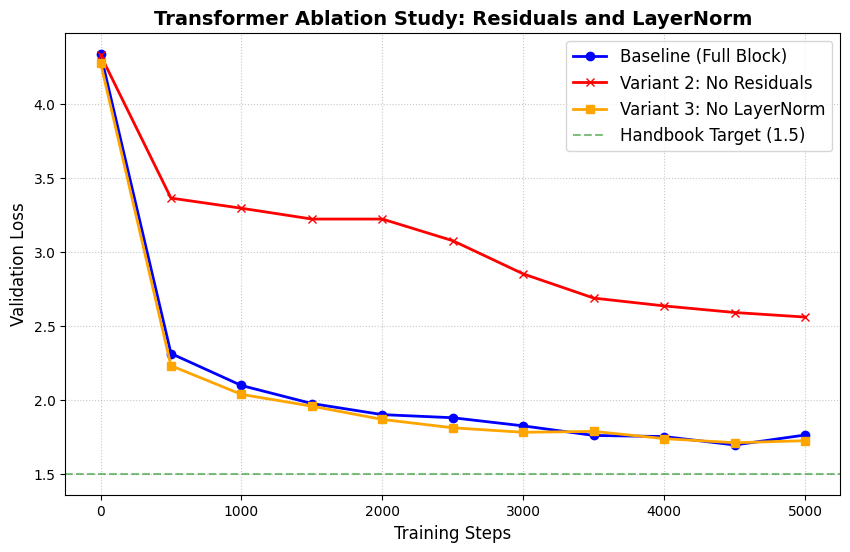

In [10]:
# --- 1. DEFINE THE BROKEN BLOCKS ---
class BlockNoResiduals(nn.Module):
    """ Variant 2: Removes the residual 'x +' highway """
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        head_size = n_embd // n_head
        self.attn = MultiHeadAttention(n_embd, n_head, head_size, block_size)
        self.ffn = FeedForward(n_embd)
        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):
        # CATASTROPHE 1: Gradients must pass through complex layers directly
        x = self.attn(self.ln1(x))
        x = self.ffn(self.ln2(x))
        return x

class BlockNoLayerNorm(nn.Module):
    """ Variant 3: Removes LayerNorm (keeps residuals) """
    def __init__(self, n_embd, n_head, block_size):
        super().__init__()
        head_size = n_embd // n_head
        self.attn = MultiHeadAttention(n_embd, n_head, head_size, block_size)
        self.ffn = FeedForward(n_embd)

    def forward(self, x):
        # CATASTROPHE 2: Activations are never re-centered/scaled
        x = x + self.attn(x)
        x = x + self.ffn(x)
        return x

class LanguageModelAblation(nn.Module):
    """ A flexible model class that accepts custom blocks """
    def __init__(self, vocab_size, block_class):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)
        self.blocks = nn.Sequential(*[block_class(n_embd, n_head, block_size) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok_emb = self.token_embedding_table(idx)
        pos_emb = self.position_embedding_table(torch.arange(T, device=device))
        x = tok_emb + pos_emb
        x = self.blocks(x)
        x = self.ln_f(x)
        logits = self.lm_head(x)

        if targets is None: return logits, None

        B, T, C = logits.shape
        logits = logits.view(B * T, C)
        targets = targets.view(B * T)
        loss = F.cross_entropy(logits, targets)
        return logits, loss

# --- 2. TRAINING FUNCTION ---
def train_ablation(model_name, block_class):
    print(f"\n--- Training {model_name} ---")
    model = LanguageModelAblation(vocab_size, block_class).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

    loss_history = []

    for iter in range(max_iters):
        if iter % 500 == 0 or iter == max_iters - 1:
            model.eval()
            with torch.no_grad():
                xb, yb = get_batch('val')
                _, val_loss = model(xb, yb)
            loss_history.append(val_loss.item())
            print(f"Step {iter}: val loss {val_loss.item():.4f}")
            model.train()

        xb, yb = get_batch('train')
        logits, loss = model(xb, yb)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

    return loss_history

# --- 3. RUN EXPERIMENTS ---
print("Starting Ablation Experiments (This might take a few minutes)...")

# Run Variant 2
loss_no_res = train_ablation("Variant 2: No Residuals", BlockNoResiduals)

# Run Variant 3
loss_no_norm = train_ablation("Variant 3: No LayerNorm", BlockNoLayerNorm)

# --- 4. GENERATING THE PLOT ---
import matplotlib.pyplot as plt

# Baseline data (from successful constant LR run!)
steps = [0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 4999]
loss_baseline = [4.3392, 2.3126, 2.0964, 1.9744, 1.8995, 1.8784, 1.8234, 1.7587, 1.7512, 1.6943, 1.7617]

plt.figure(figsize=(10, 6))
plt.plot(steps, loss_baseline, marker='o', label='Baseline (Full Block)', color='blue', linewidth=2)
plt.plot(steps, loss_no_res, marker='x', label='Variant 2: No Residuals', color='red', linewidth=2)
plt.plot(steps, loss_no_norm, marker='s', label='Variant 3: No LayerNorm', color='orange', linewidth=2)

plt.axhline(y=1.5, color='green', linestyle='--', alpha=0.5, label='Handbook Target (1.5)')

plt.title('Transformer Ablation Study: Residuals and LayerNorm', fontsize=14, fontweight='bold')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Validation Loss', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Save the plot
plt.savefig('task2_ablation_plot.png', dpi=300, bbox_inches='tight')
print("\nPlot saved successfully as 'task2_ablation_plot.png'!")
plt.show()